# Spotify Music Analysis

This project explores Spotify track data using exploratory data analysis, machine learning, and clustering.
The main goals of this project are:

- Explore Spotify track features

- Understand what affects song popularity

- Build a machine learning model to predict popularity

- Use clustering to group similar songs

In [122]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [123]:
df = pd.read_csv("dataset.csv")

In [124]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [125]:
df.tail()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


## 1. Dataset Overview

In this section, I inspect the size, columns, data types, and missing values in the dataset.

In [126]:
df.shape

(114000, 21)

In [127]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [129]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## 2. Summary Statistics

This section provides basic statistical information about the numerical columns.

In [130]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 3. Data Cleaning

In this section, I remove unnecessary columns, check duplicates, and handle missing values.

In [131]:
df = df.drop(columns=["Unnamed: 0"])

In [132]:
df.duplicated().sum()

np.int64(450)

In [133]:
df = df.drop_duplicates()

In [134]:
df["track_id"].duplicated().sum()

np.int64(23809)

In [135]:
df[df["track_id"].duplicated(keep=False)][
    ["track_id", "track_name", "artists", "track_genre", "popularity"]
].sort_values("track_id").head(20)

,track_id,track_name,artists,track_genre,popularity
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill,0
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul,0
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock,38
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska,38
2106,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alt-rock,86
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock,86
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alternative,86
33178,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,emo,58
94239,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,sad,58
97533,006rHBBNLJMpQs8fRC2GDe,Agora Estou Sofrendo - Ao Vivo,Calcinha Preta;Gusttavo Lima,sertanejo,47


In [136]:
df = df.dropna()

In [137]:
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## 4. Exploratory Data Analysis

In this section, I explore the distribution of popularity, genres, and Spotify audio features.

In [138]:
df.shape

(113549, 20)

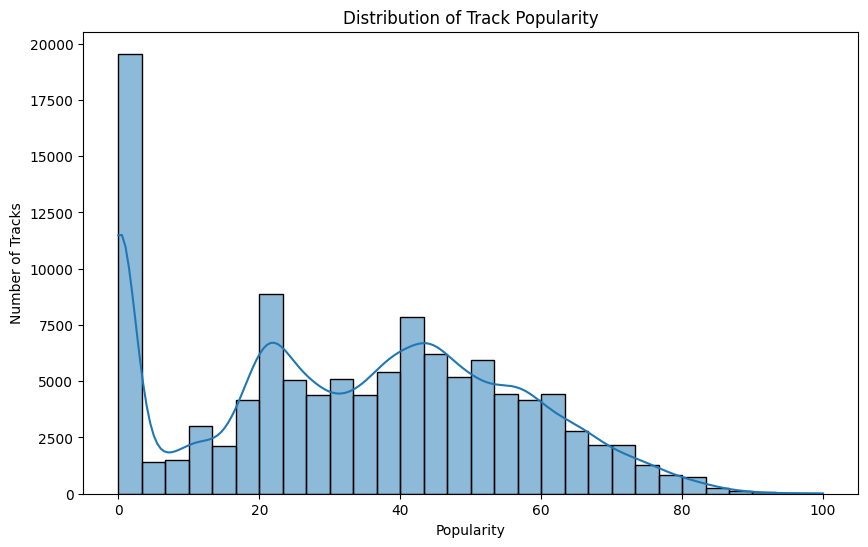

In [139]:
plt.figure(figsize=(10, 6))
sns.histplot(df["popularity"], bins=30, kde=True)
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.show()

The popularity scores are not evenly distributed. Many tracks have low to medium popularity, while fewer tracks have very high popularity.

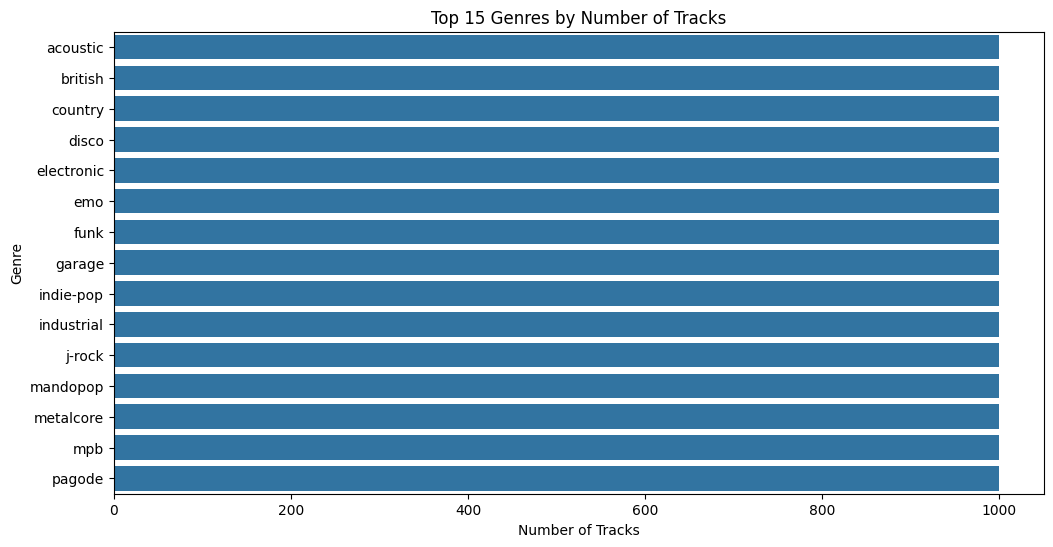

In [140]:
top_genres = df["track_genre"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 15 Genres by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")
plt.show()

The top 15 genres each contain approximately 1000 tracks. This suggests that the dataset is relatively balanced across genres, rather than reflecting real-world Spotify genre popularity. Genre count comparisons should be interpreted as part of the dataset structure rather than as evidence of which genres are most common on Spotify.

### Explicit vs Non-Explicit Tracks

This section checks how many songs are marked as explicit or non-explicit.

In [141]:
df["explicit"].value_counts()

explicit
False    103831
True       9718
Name: count, dtype: int64

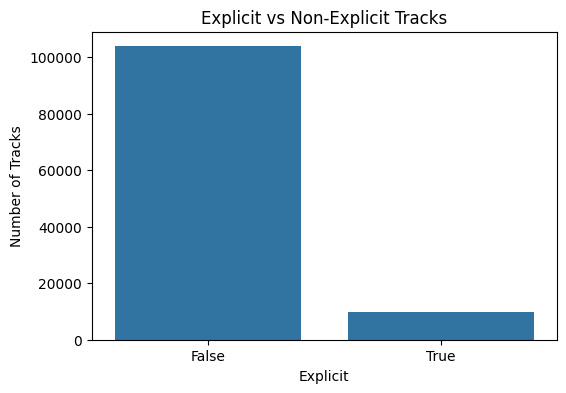

In [142]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="explicit")

plt.title("Explicit vs Non-Explicit Tracks")
plt.xlabel("Explicit")
plt.ylabel("Number of Tracks")

plt.show()

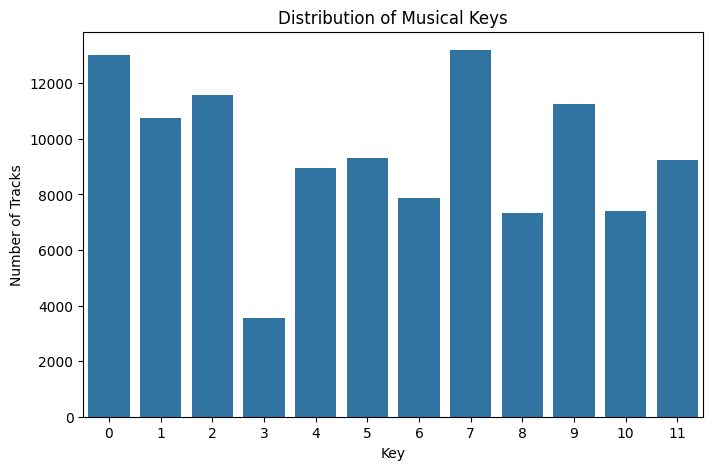

In [143]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="key")

plt.title("Distribution of Musical Keys")
plt.xlabel("Key")
plt.ylabel("Number of Tracks")

plt.show()

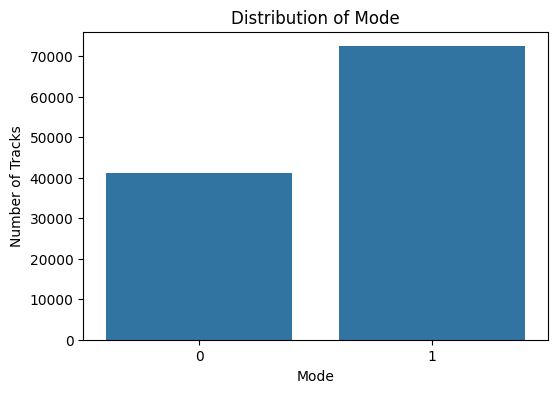

In [144]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="mode")

plt.title("Distribution of Mode")
plt.xlabel("Mode")
plt.ylabel("Number of Tracks")

plt.show()

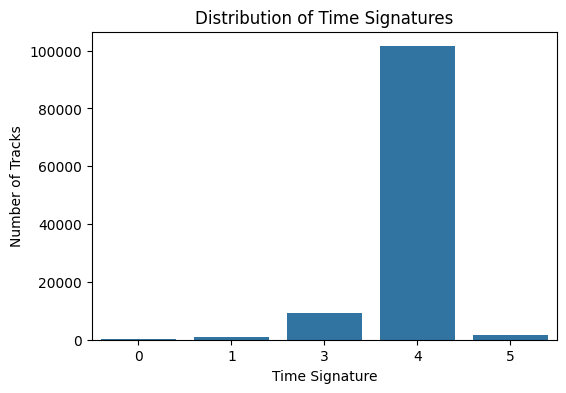

In [145]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="time_signature")

plt.title("Distribution of Time Signatures")
plt.xlabel("Time Signature")
plt.ylabel("Number of Tracks")

plt.show()


### Audio Feature Distributions

This section explores the distributions of Spotify audio features such as danceability, energy, acousticness, instrumentalness, liveness, valence, and speechiness.

In [146]:
audio_features = [
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

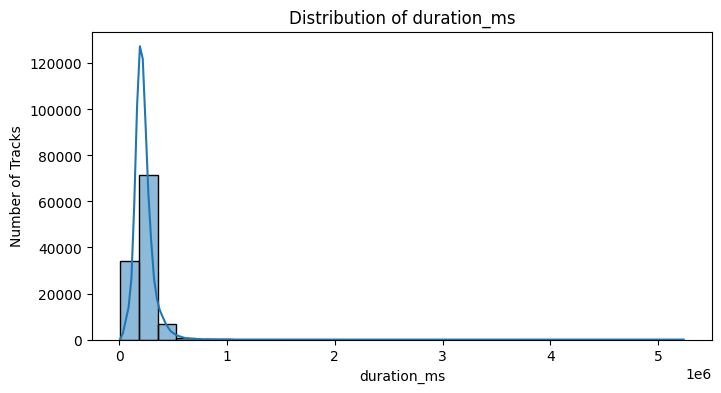

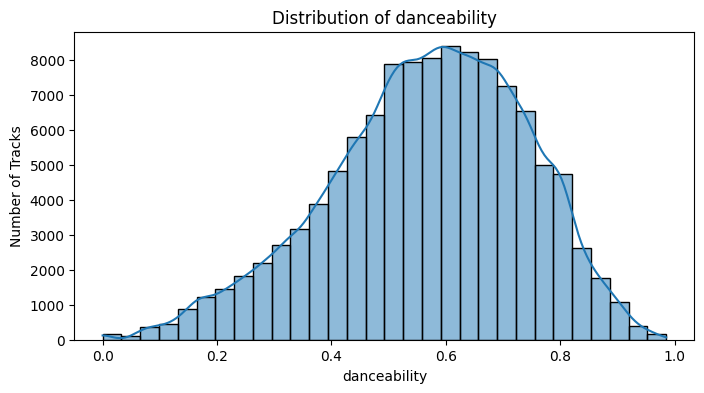

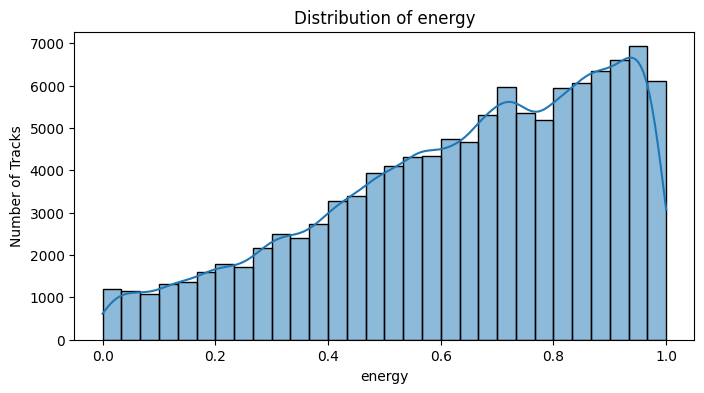

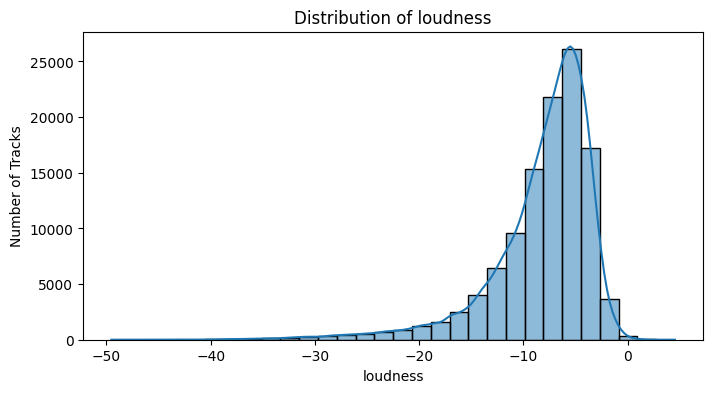

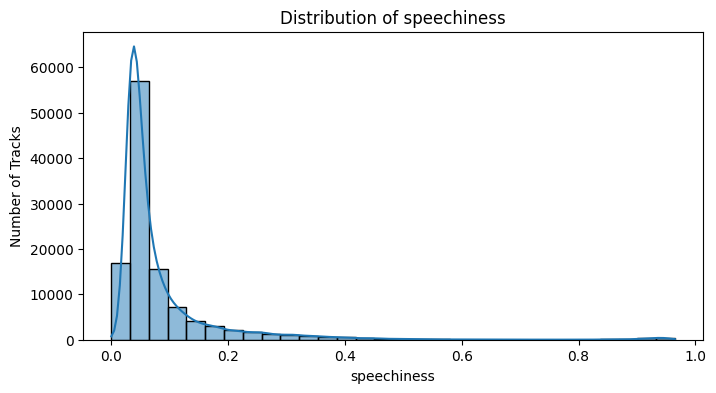

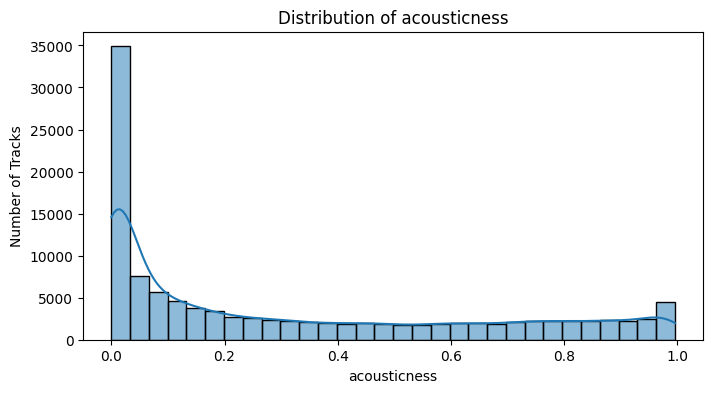

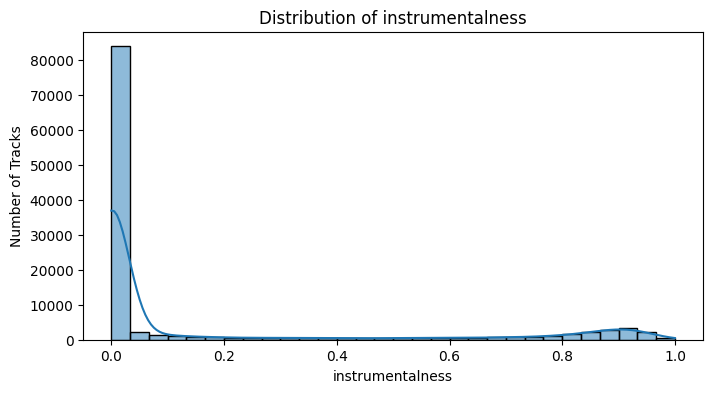

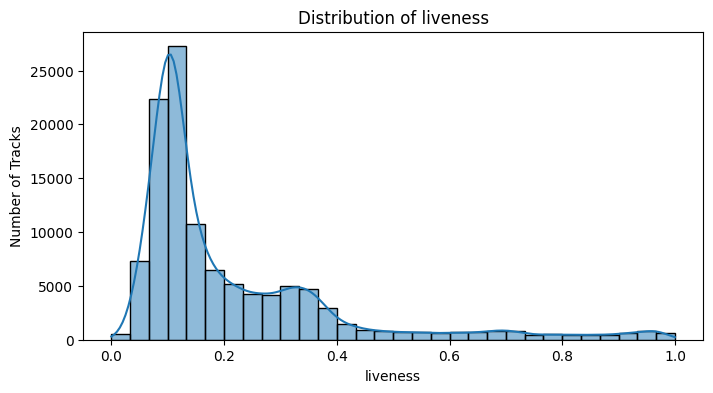

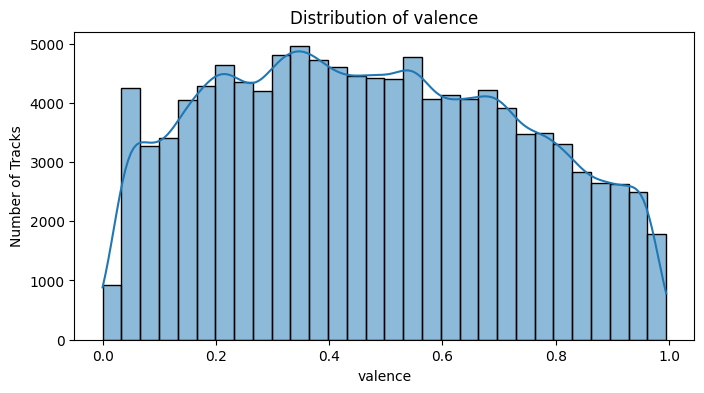

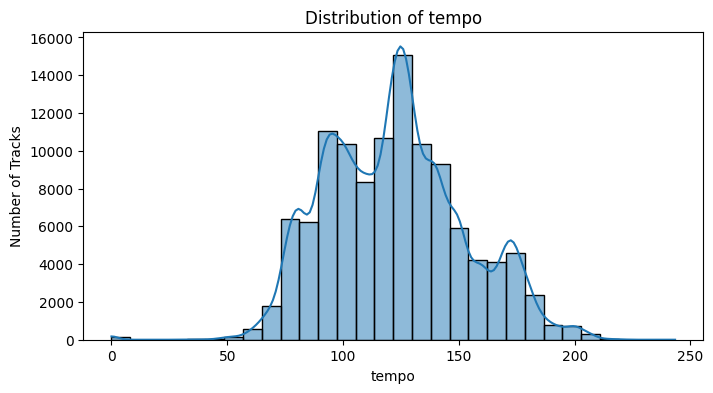

In [147]:
for feature in audio_features:
    plt.figure(figsize=(8,4))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Tracks")
    plt.show()

In [148]:
df["duration_min"]= df["duration_ms"]/60000

### Summary of Numerical Feature Distributions

The numerical audio features show different distribution patterns. Danceability is mostly centered around medium-to-high values, while energy is more concentrated toward higher values. Speechiness, instrumentalness, and liveness are strongly right-skewed, meaning most tracks have low values for these features.

Acousticness has many values near 0, but also includes some highly acoustic tracks near 1. Valence is broadly distributed across the full range, showing that the dataset contains tracks with a variety of emotional tones. Tempo is mostly concentrated between approximately 90 and 150 BPM.

Duration and loudness contain noticeable outliers. Duration includes some unusually long tracks, while loudness includes some very quiet tracks. These features may require additional handling before machine learning or clustering.

Overall, these distributions show that the dataset contains a wide variety of track characteristics and that feature scaling will be important before modeling or clustering.

## Popularity Analysis

In this section, I compare track popularity across different categories and examine which features may be related to popularity.

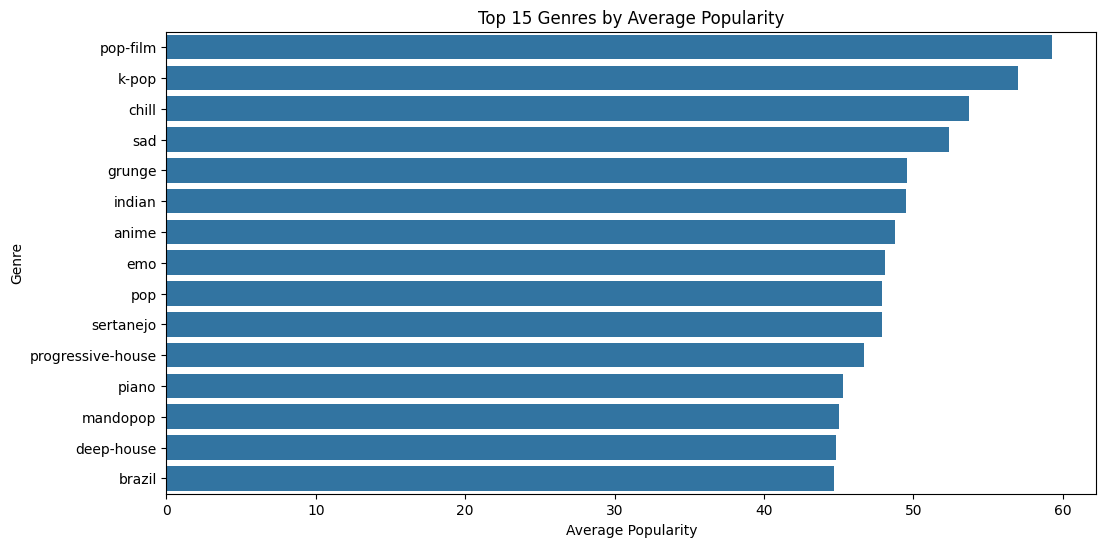

In [149]:
genre_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

sns.barplot(x=genre_popularity.values, y=genre_popularity.index)

plt.title("Top 15 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

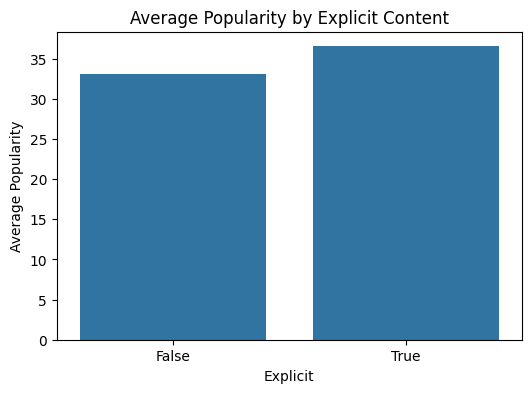

In [150]:
explicit_popularity = df.groupby("explicit")["popularity"].mean()

plt.figure(figsize=(6, 4))

sns.barplot(x=explicit_popularity.index, y=explicit_popularity.values)

plt.title("Average Popularity by Explicit Content")
plt.xlabel("Explicit")
plt.ylabel("Average Popularity")

plt.show()

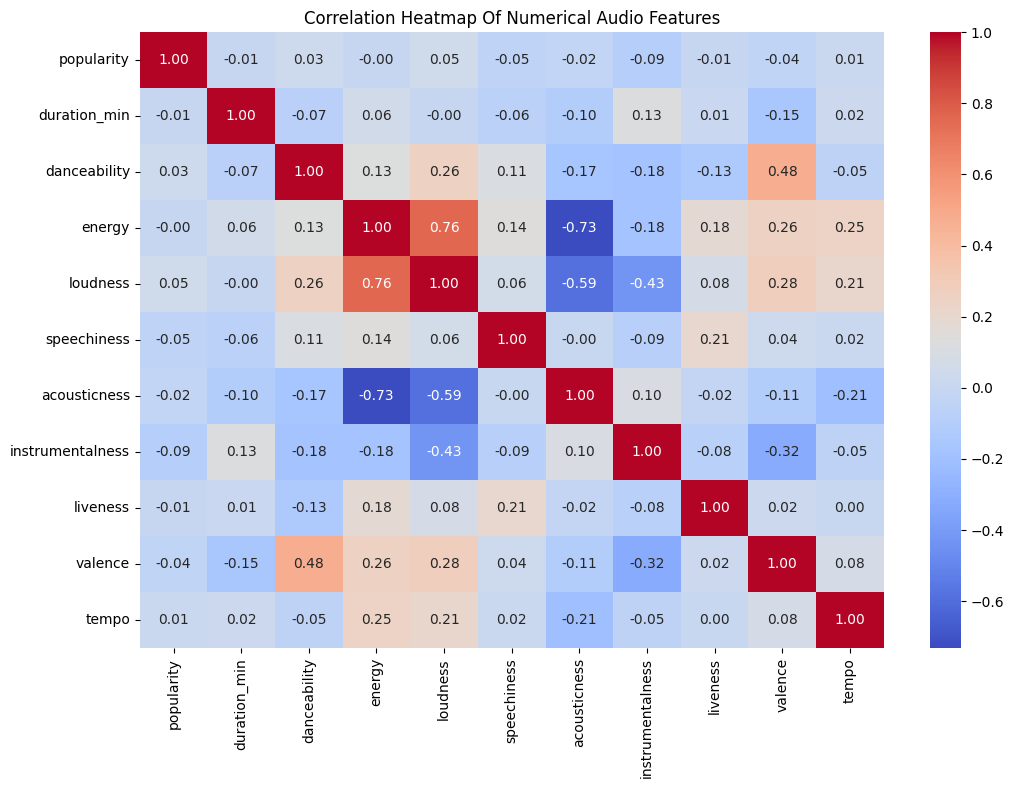

In [151]:
numeric_features = [
    "popularity",
    "duration_min",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap = "coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap Of Numerical Audio Features")
plt.show()


### Correlation Heatmap Summary

The strongest positive correlation is between energy and loudness, indicating that higher-energy tracks tend to be louder. Energy also has a strong negative correlation with acousticness, suggesting that acoustic tracks are generally less energetic. Loudness and acousticness also show a negative relationship, meaning more acoustic tracks tend to be quieter.

Danceability has a moderate positive relationship with valence, which suggests that more danceable songs often sound more positive or upbeat.

Popularity has very weak correlations with the numerical audio features. This suggests that popularity is not strongly explained by audio features alone and may depend on other factors such as artist recognition, marketing, playlists, or listener trends.

In [152]:
df[numeric_features].corr()["popularity"].sort_values(ascending=False)

popularity          1.000000
loudness            0.047368
danceability        0.034407
tempo               0.012187
energy             -0.002447
liveness           -0.005668
duration_min       -0.007928
acousticness       -0.022356
valence            -0.041097
speechiness        -0.045463
instrumentalness   -0.094718
Name: popularity, dtype: float64

The correlation values confirm that no numerical audio feature has a strong linear relationship with popularity.

## Machine Learning: Predicting Track Popularity

In this section, I build a regression model to predict track popularity based on Spotify audio features and selected categorical features.

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [154]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


### Selecting Features and Target

The target variable is `popularity` because the goal is to predict a track's popularity score. I selected numerical audio features and selected categorical features that may help explain popularity.

In [155]:
target = "popularity"

numeric_features = [
    "duration_min",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

categorical_features = [
    "explicit",
    "key",
    "mode",
    "time_signature",
    "track_genre"
]

X = df[numeric_features + categorical_features]
y = df[target]

### Train-Test Split

I split the dataset into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate how well the model performs on unseen data.

In [156]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42
)

In [157]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (90839, 15)
X_test shape: (22710, 15)
y_train shape: (90839,)
y_test shape: (22710,)


In [158]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### Model Training

I trained two regression models to predict track popularity. Linear Regression is used as a simple baseline model, while Random Forest Regressor is used as a more flexible model that can capture non-linear relationships. Comparing both models helps determine whether the more complex model improves prediction performance.

In [159]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [160]:
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 14.228352301530505
RMSE: 19.386665142408017
R² Score: 0.2507327122592017


In [161]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [162]:
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 10.462706715330528
RMSE: 15.543770985841864
R² Score: 0.5183369492170798


### Model Evaluation Summary

The Random Forest Regressor performed better than the Linear Regression model across all evaluation metrics. Random Forest achieved a lower MAE and RMSE, meaning its predictions were closer to the actual popularity scores. It also achieved a higher R² score, explaining about 52% of the variation in track popularity compared to about 25% for Linear Regression.

This suggests that the relationship between Spotify audio features, categorical features, and popularity is not purely linear. The Random Forest model is better able to capture non-linear patterns and feature interactions.

In [163]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,14.228352,19.386665,0.250733
1,Random Forest,10.462707,15.543771,0.518337


### Feature Importance

Since Random Forest was the best-performing model, I examined feature importance to understand which variables contributed most to its predictions.

In [164]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["regressor"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
5,num__acousticness,0.067307
0,num__duration_min,0.066539
3,num__loudness,0.065731
9,num__tempo,0.064957
8,num__valence,0.064886
4,num__speechiness,0.064884
1,num__danceability,0.063278
2,num__energy,0.061300
7,num__liveness,0.057484
6,num__instrumentalness,0.045572


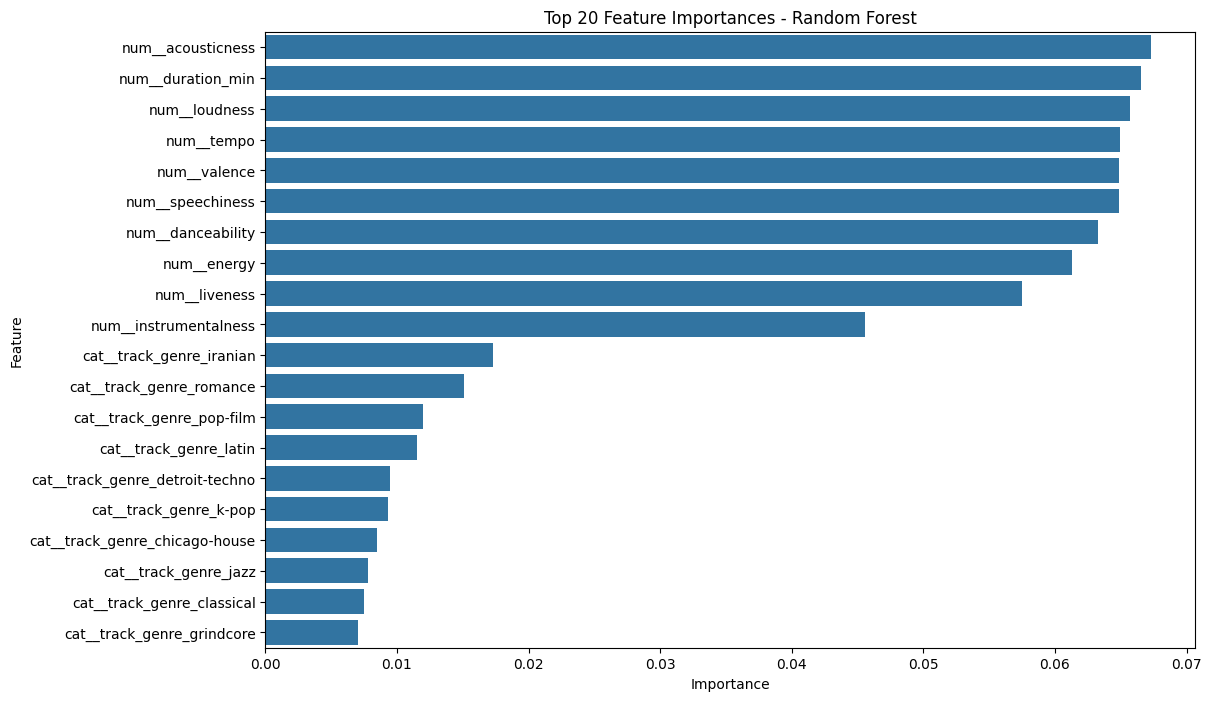

In [165]:
top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

The Random Forest feature importance results show that the model relied mostly on numerical audio features such as acousticness, duration, loudness, tempo, valence, speechiness, danceability, and energy. The importance values for these features are relatively close, which suggests that no single feature dominates the prediction. Instead, the model uses a combination of audio characteristics to estimate popularity.

Some one-hot encoded genre features also appear among the top features, such as Iranian, romance, pop-film, Latin, and K-pop. This indicates that genre information also contributed to the model's predictions. 

In [166]:
prediction_results = X_test.copy()
prediction_results["actual_popularity"] = y_test
prediction_results["predicted_popularity"] = rf_pred
prediction_results["prediction_error"] = abs(
    prediction_results["actual_popularity"] - prediction_results["predicted_popularity"]
)

prediction_results.head()

,duration_min,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,explicit,key,mode,time_signature,track_genre,actual_popularity,predicted_popularity,prediction_error
77407,3.475200,0.427,0.703,-7.007,0.0487,0.575000,0.000000,0.9350,0.700,84.440,False,9,1,4,pagode,45,45.840,0.840
96769,1.756483,0.652,0.701,-8.178,0.0348,0.532000,0.000002,0.6020,0.928,158.124,False,2,1,4,samba,37,37.430,0.430
6993,2.931767,0.573,0.976,-4.004,0.1790,0.000046,0.022200,0.2720,0.315,114.020,False,1,0,4,black-metal,17,29.310,12.310
75387,4.739550,0.281,0.141,-19.125,0.0334,0.978000,0.883000,0.1030,0.206,135.356,False,4,0,3,new-age,23,26.223,3.223
61284,4.821333,0.403,0.921,-2.756,0.1100,0.032600,0.000000,0.0985,0.574,177.824,False,9,1,4,j-idol,25,24.620,0.380


## Clustering: Grouping Similar Tracks

In this section, I use clustering to group tracks based on their audio characteristics. 

In [167]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [168]:
clustering_features = [
    "duration_min",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X_cluster = df[clustering_features]

In [169]:
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [170]:
X_cluster_scaled.shape

(113549, 10)

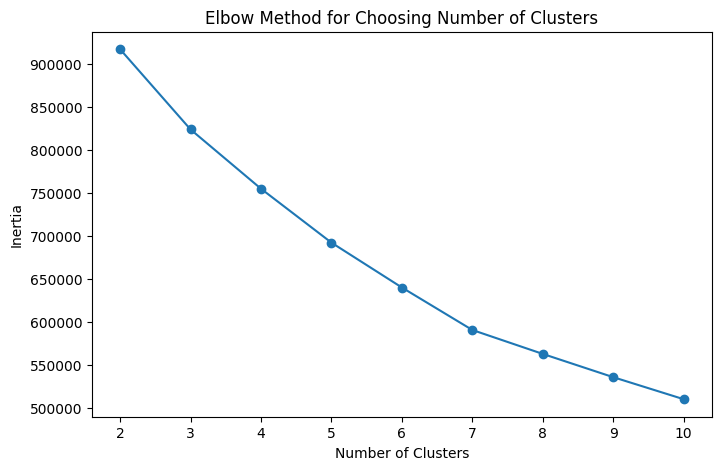

In [171]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

The elbow curve does not show a very sharp elbow, but the decrease in inertia starts to slow around 7 clusters. So I selected 7 clusters for the K-Means model.

In [172]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(X_cluster_scaled)

In [173]:
df["cluster"].value_counts().sort_index()

cluster
0     7314
1    11406
2    26487
3     7744
4    36484
5     1109
6    23005
Name: count, dtype: int64

In [174]:
cluster_summary = df.groupby("cluster")[clustering_features].mean()

cluster_summary

,duration_min,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,,
0,3.569445,0.348357,0.171456,-21.136515,0.051062,0.864057,0.788339,0.162330,0.185912,103.158587
1,5.168084,0.588476,0.742842,-8.473463,0.069987,0.100126,0.777189,0.167860,0.336340,126.862690
2,3.913953,0.470353,0.814125,-5.350898,0.082943,0.075598,0.037876,0.192675,0.371105,139.742939
3,3.942735,0.523017,0.754710,-6.972232,0.087008,0.281190,0.067231,0.737405,0.512215,123.443538
4,3.461988,0.704262,0.722514,-6.361807,0.093668,0.207179,0.018783,0.164393,0.692439,117.817739
5,3.623737,0.576317,0.666516,-11.161065,0.829273,0.729049,0.009810,0.644125,0.446908,101.824566
6,3.566998,0.533965,0.377063,-10.631861,0.053694,0.680406,0.036052,0.157691,0.395342,113.137669


### Cluster Interpretation

The cluster summary table shows the average audio feature values for each cluster. 

Cluster 0 has high acousticness and high instrumentalness, with low energy and low valence. This suggests calm acoustic/instrumental tracks.

Cluster 1 has high energy, high instrumentalness, low acousticness, and a longer average duration. This may represent energetic instrumental tracks.

Cluster 2 has high energy, high loudness, low acousticness, and low instrumentalness. This suggests loud, energetic vocal tracks.

Cluster 3 has high energy and very high liveness, which may represent live recordings or tracks with audience/background noise.

Cluster 4 has high danceability, high energy, and high valence. This cluster likely represents upbeat, danceable, positive-sounding tracks.

Cluster 5 has very high speechiness, high acousticness, and high liveness. This may represent spoken-word, comedy, podcast-like, or live speech-heavy tracks.

Cluster 6 has high acousticness, lower energy, and low instrumentalness. This suggests mellow acoustic vocal tracks.

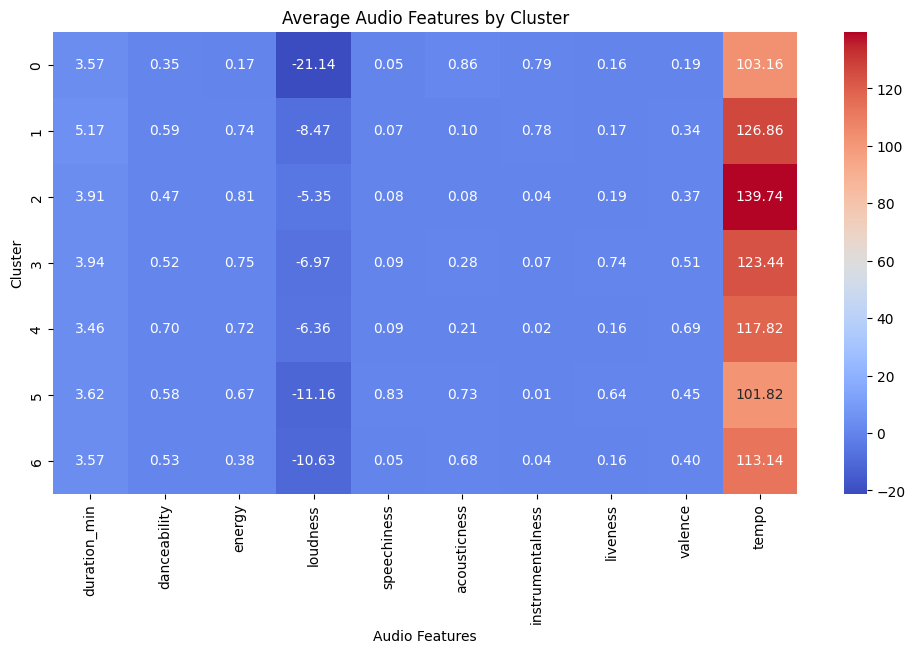

In [175]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Average Audio Features by Cluster")
plt.xlabel("Audio Features")
plt.ylabel("Cluster")

plt.show()

In [176]:
cluster_summary_scaled = (

    cluster_summary - cluster_summary.mean()

) / cluster_summary.std()

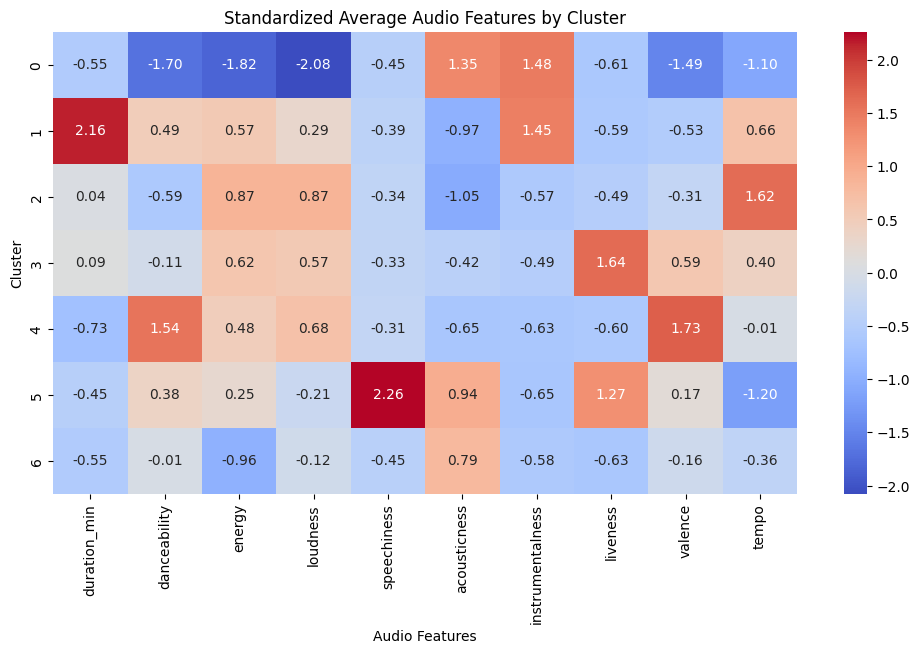

In [177]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_summary_scaled,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Standardized Average Audio Features by Cluster")
plt.xlabel("Audio Features")
plt.ylabel("Cluster")

plt.show()

### Average Popularity by Cluster

Popularity was not used to create the clusters. However, comparing average popularity by cluster helps show whether certain audio-based groups tend to be more or less popular.

In [178]:
cluster_popularity = (
    df.groupby("cluster")["popularity"]
    .mean()
    .sort_values(ascending=False)
)

cluster_popularity

cluster
2    35.674218
3    35.427428
6    34.366529
4    33.178133
0    28.843041
1    28.448273
5    25.420198
Name: popularity, dtype: float64

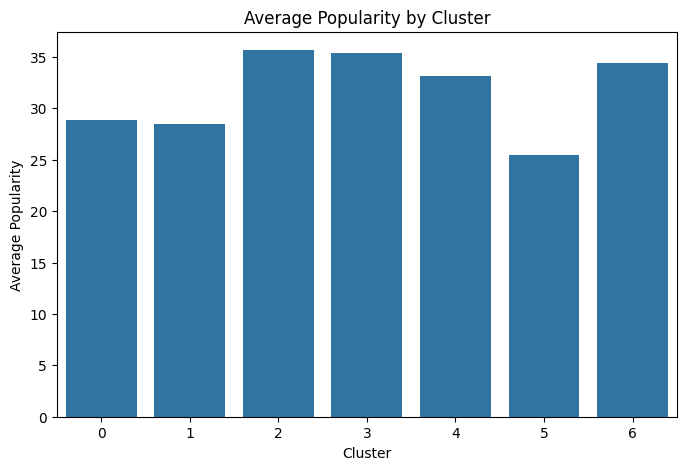

In [179]:
plt.figure(figsize=(8, 5))

sns.barplot(x=cluster_popularity.index, y=cluster_popularity.values)

plt.title("Average Popularity by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Popularity")

plt.show()

### PCA Visualization of Clusters

To visualize the clusters, I used PCA to reduce the scaled audio features from 10 dimensions to 2 dimensions. 

In [180]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_cluster_scaled)

In [181]:
pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "cluster": df["cluster"]
})

pca_df.head()

,PCA1,PCA2,cluster
0,0.635851,1.025576,4
1,-3.330136,1.312477,6
2,-1.392826,-0.163919,6
3,-3.387497,-0.328990,6
4,-0.992437,0.303259,6


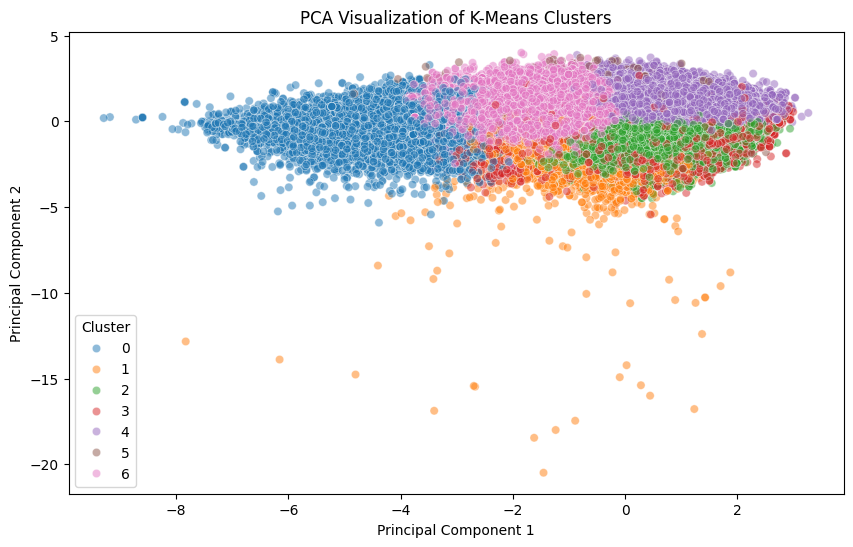

In [182]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="cluster",
    palette="tab10",
    alpha=0.5
)

plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [183]:
df.to_csv("outputs/spotify_final_with_clusters.csv", index=False)